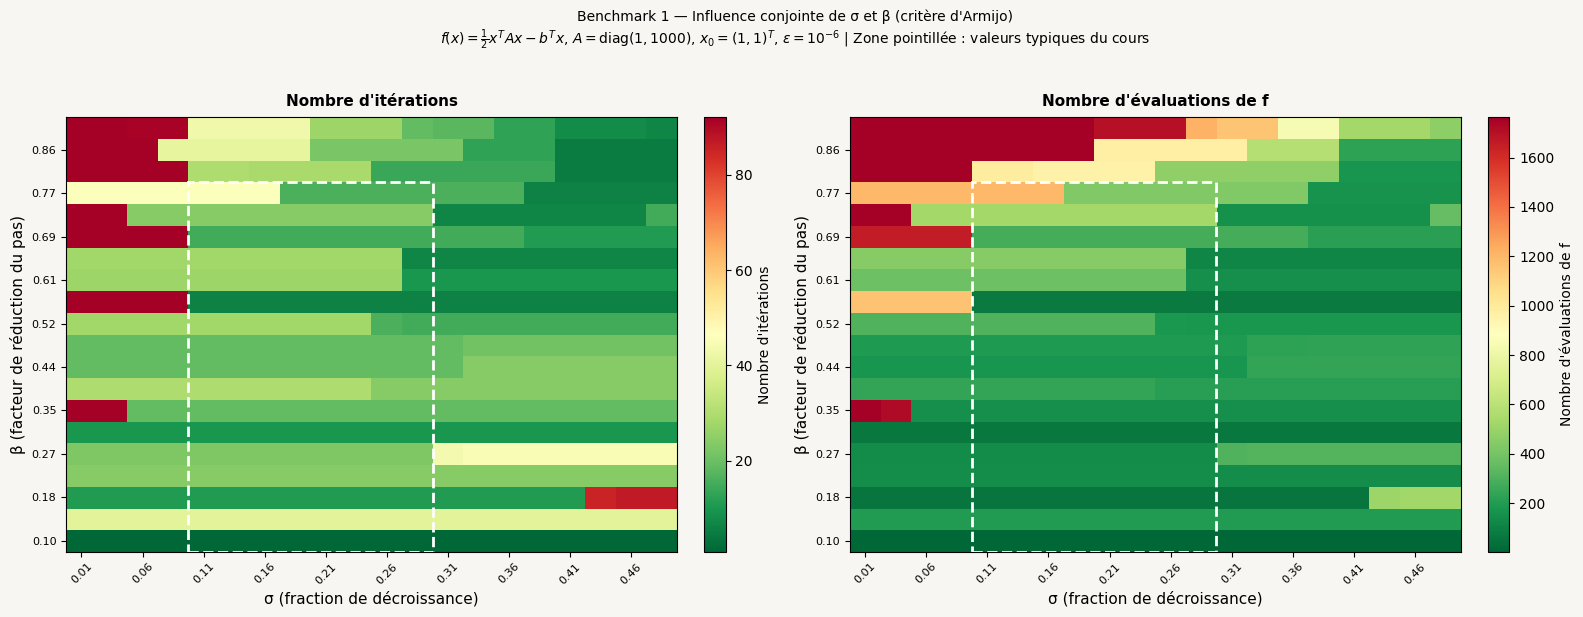

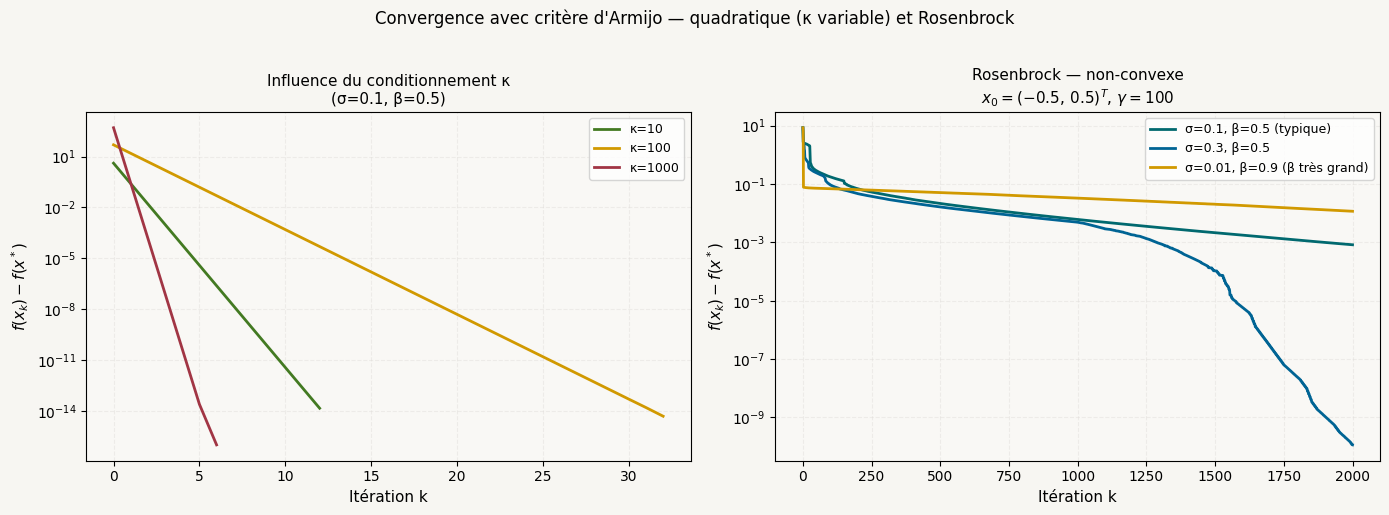

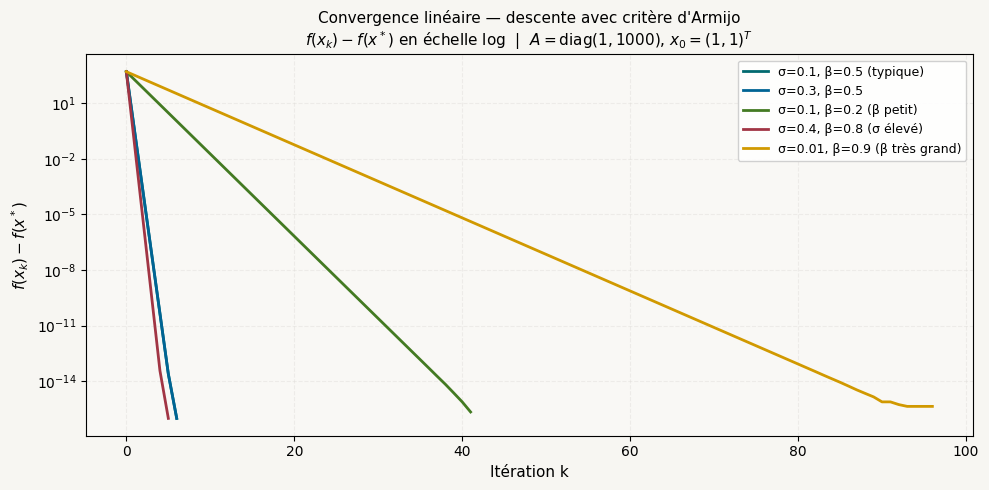

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

%matplotlib inline

# ── Setup de base ──────────────────────────────────────────────────────
np.random.seed(42)
x0 = np.array([1.0, 1.0])

# ── Fonctions quadratiques (paramétrées par κ) ─────────────────────────
def make_quadratic(kappa):
    A = np.diag([1.0, float(kappa)])
    b = np.array([1.0, 1.0])
    x_star = np.linalg.solve(A, b)
    f_star = 0.5 * x_star @ A @ x_star - b @ x_star
    f    = lambda x: 0.5 * x @ A @ x - b @ x
    grad = lambda x: A @ x - b
    return A, b, x_star, f_star, f, grad

A, b, x_star, f_star, f, grad_f = make_quadratic(1000)

# ── Rosenbrock + gradient analytique ──────────────────────────────────
def rosenbrock(x, gamma=100):
    return (x[0] - 1)**2 + gamma * (x[0]**2 - x[1])**2

def grad_rosenbrock(x, gamma=100):
    return np.array([
        2*(x[0] - 1) + 4*gamma*x[0]*(x[0]**2 - x[1]),
        -2*gamma*(x[0]**2 - x[1])
    ])

# ── Descente Armijo générique ──────────────────────────────────────────
def armijo_descent(func, grad_func, x0, sigma, beta, max_iter=10000, tol=1e-6):
    x = x0.copy()
    n_iter, n_evals, converged = 0, 0, False
    for k in range(max_iter):
        g = grad_func(x)
        if np.linalg.norm(g) < tol:
            converged = True
            break
        d = -g
        alpha = 1.0
        n_evals += 1
        while func(x + alpha * d) > func(x) + sigma * alpha * (g @ d):
            alpha *= beta
            n_evals += 1
        x = x + alpha * d
        n_iter += 1
    return n_iter, n_evals, converged

def armijo_descent_trace(func, grad_func, x0, sigma, beta, f_star=None, max_iter=2000, tol=1e-6):
    x = x0.copy()
    ref = f_star if f_star is not None else func(x0)
    trace = [func(x) - ref]
    for k in range(max_iter):
        g = grad_func(x)
        if np.linalg.norm(g) < tol:
            break
        d = -g
        alpha = 1.0
        while func(x + alpha * d) > func(x) + sigma * alpha * (g @ d):
            alpha *= beta
        x = x + alpha * d
        trace.append(max(func(x) - ref, 1e-16))
    return trace

# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — Heatmaps (σ, β) sur quadratique κ=1000
# ══════════════════════════════════════════════════════════════════════
sigmas = np.linspace(0.01, 0.49, 20)
betas  = np.linspace(0.1,  0.9,  20)

iters_grid = np.zeros((len(betas), len(sigmas)))
evals_grid = np.zeros((len(betas), len(sigmas)))

for i, sigma in enumerate(sigmas):
    for j, beta in enumerate(betas):
        n_iter, n_evals, _ = armijo_descent(f, grad_f, x0, sigma, beta)
        iters_grid[j, i] = n_iter
        evals_grid[j, i] = n_evals

iters_clipped = np.clip(iters_grid, None, np.percentile(iters_grid, 95))
evals_clipped = np.clip(evals_grid, None, np.percentile(evals_grid, 95))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#f7f6f2")

for ax, (data, title) in zip(axes, [(iters_clipped, "Nombre d'itérations"),
                                     (evals_clipped, "Nombre d'évaluations de f")]):
    ax.set_facecolor("#f9f8f5")
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="RdYlGn_r", interpolation="nearest")
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(title, fontsize=10)
    xticks = np.arange(0, len(sigmas), 2)
    yticks = np.arange(0, len(betas), 2)
    ax.set_xticks(xticks)
    ax.set_xticklabels([f"{sigmas[i]:.2f}" for i in xticks], rotation=45, fontsize=8)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{betas[i]:.2f}" for i in yticks], fontsize=8)
    ax.set_xlabel("σ (fraction de décroissance)", fontsize=11)
    ax.set_ylabel("β (facteur de réduction du pas)", fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    s_lo = np.argmin(np.abs(sigmas - 0.10))
    s_hi = np.argmin(np.abs(sigmas - 0.30))
    b_lo = np.argmin(np.abs(betas - 0.10))
    b_hi = np.argmin(np.abs(betas - 0.79))
    rect = Rectangle((s_lo-0.5, b_lo-0.5), s_hi-s_lo+1, b_hi-b_lo+1,
                      linewidth=2, edgecolor="white", facecolor="none", linestyle="--", zorder=5)
    ax.add_patch(rect)

fig.suptitle(
    "Benchmark 1 — Influence conjointe de σ et β (critère d'Armijo)\n"
    r"$f(x)=\frac{1}{2}x^TAx-b^Tx$, $A=\mathrm{diag}(1,1000)$, $x_0=(1,1)^T$, $\varepsilon=10^{-6}$"
    " | Zone pointillée : valeurs typiques du cours",
    fontsize=10, y=1.02
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — Convergence : κ variable (gauche) + Rosenbrock (droite)
# ══════════════════════════════════════════════════════════════════════
kappas       = [10, 100, 1000]
kappa_colors = ["#437a22", "#d19900", "#a13544"]

combos = [
    (0.1,  0.5, "#01696f", "σ=0.1, β=0.5 (typique)"),
    (0.3,  0.5, "#006494", "σ=0.3, β=0.5"),
    (0.01, 0.9, "#d19900", "σ=0.01, β=0.9 (β très grand)"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#f7f6f2")

# ── Panneau gauche : influence de κ ────────────────────────────────────
ax = axes[0]
ax.set_facecolor("#f9f8f5")

for kappa_val, color in zip(kappas, kappa_colors):
    _, _, _, f_star_k, fk, gk = make_quadratic(kappa_val)
    trace = armijo_descent_trace(fk, gk, x0, sigma=0.1, beta=0.5, f_star=f_star_k)
    ax.semilogy(trace, color=color, linewidth=2, label=f"κ={kappa_val}")

ax.set_xlabel("Itération k", fontsize=11)
ax.set_ylabel(r"$f(x_k) - f(x^*)$", fontsize=11)
ax.set_title("Influence du conditionnement κ\n(σ=0.1, β=0.5)", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, which="both", linestyle="--", alpha=0.4, color="#dcd9d5")

# ── Panneau droit : Rosenbrock (gradient analytique) ──────────────────
ax = axes[1]
ax.set_facecolor("#f9f8f5")

x0_rb   = np.array([-0.5, 0.5])
rb_star = 0.0

for sigma, beta, color, label in combos:
    trace = armijo_descent_trace(
        rosenbrock,
        grad_rosenbrock,
        x0_rb, sigma, beta,
        f_star=rb_star
    )
    ax.semilogy(trace, color=color, linewidth=2, label=label)

ax.set_xlabel("Itération k", fontsize=11)
ax.set_ylabel(r"$f(x_k) - f(x^*)$", fontsize=11)
ax.set_title("Rosenbrock — non-convexe\n"
             r"$x_0=(-0.5,\,0.5)^T$, $\gamma=100$", fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, which="both", linestyle="--", alpha=0.4, color="#dcd9d5")

fig.suptitle(
    "Convergence avec critère d'Armijo — quadratique (κ variable) et Rosenbrock",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════
# FIGURE 3 — Courbes de convergence multi (σ,β) sur κ=1000
# ══════════════════════════════════════════════════════════════════════
combos_orig = [
    (0.1,  0.5, "#01696f", "σ=0.1, β=0.5 (typique)"),
    (0.3,  0.5, "#006494", "σ=0.3, β=0.5"),
    (0.1,  0.2, "#437a22", "σ=0.1, β=0.2 (β petit)"),
    (0.4,  0.8, "#a13544", "σ=0.4, β=0.8 (σ élevé)"),
    (0.01, 0.9, "#d19900", "σ=0.01, β=0.9 (β très grand)"),
]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#f7f6f2")
ax.set_facecolor("#f9f8f5")

for sigma, beta, color, label in combos_orig:
    trace = armijo_descent_trace(f, grad_f, x0, sigma, beta, f_star=f_star)
    ax.semilogy(trace, color=color, linewidth=2, label=label)

ax.set_xlabel("Itération k", fontsize=11)
ax.set_ylabel(r"$f(x_k) - f(x^*)$", fontsize=11)
ax.set_title(
    "Convergence linéaire — descente avec critère d'Armijo\n"
    r"$f(x_k)-f(x^*)$ en échelle log  |  $A=\mathrm{diag}(1,1000)$, $x_0=(1,1)^T$",
    fontsize=11
)
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(True, which="both", linestyle="--", alpha=0.4, color="#dcd9d5")
plt.tight_layout()
plt.show()